<a href="https://colab.research.google.com/github/Muhammad-Umer1132/AI-ML-Internship-Tasks/blob/main/Task2_Developerhub_Internship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Task 2: Predict Future Stock Prices (Short-Term)**

**Problem Statement**:
Stock price prediction is one of the most popular applications of Machine Learning in finance. The goal of this task is to use **historical stock market data** to predict the **next day's closing price** of a chosen stock using regression models.

**Dataset:**
- **Source:** Yahoo Finance via the `yfinance` Python library (real, live data)
- **Stock Selected:** Apple Inc. (`AAPL`)
- **Time Range:** Last 2 years of trading data
- **Features Used:** `Open`, `High`, `Low`, `Volume` → to predict `Close`


**Objectives:**
1. Fetch real stock data using `yfinance`
2. Preprocess and engineer features for next-day prediction
3. Train both **Linear Regression** and **Random Forest** models
4. Evaluate model performance
5. Visualize actual vs predicted closing prices

**Step 1: Install & Import Required Libraries**

In [20]:
#Install yfinance
!pip install yfinance --quiet
print("yfinance installed!")

yfinance installed!


In [21]:
import pandas as pd
import numpy as np

# ── Stock Data Fetching ──
import yfinance as yf

# ── Machine Learning ──
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# ── Visualization ──
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# ── Settings ──
%matplotlib inline
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.float_format', '{:.4f}'.format)

print("All libraries imported successfully!")

All libraries imported successfully!


**Step 2: Fetch Stock Data Using yfinance**

In [22]:
# ── Configuration ──
STOCK_TICKER = 'AAPL'   # Apple Inc. — change to 'TSLA', 'GOOGL', etc. if preferred
START_DATE   = '2022-01-01'
END_DATE     = '2024-12-31'

# ── Download historical data from Yahoo Finance ──
print(f"📡 Fetching data for {STOCK_TICKER} from {START_DATE} to {END_DATE}...")
raw_df = yf.download(STOCK_TICKER, start=START_DATE, end=END_DATE)

print(f"\n Data fetched successfully!")
print(f"   Total trading days: {len(raw_df)}")
print(f"   Date range: {raw_df.index[0].date()} → {raw_df.index[-1].date()}")

/tmp/ipykernel_1591/3949101508.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_df = yf.download(STOCK_TICKER, start=START_DATE, end=END_DATE)
[*********************100%***********************]  1 of 1 completed

📡 Fetching data for AAPL from 2022-01-01 to 2024-12-31...

 Data fetched successfully!
   Total trading days: 752
   Date range: 2022-01-03 → 2024-12-30


In [4]:
# Preview the raw data
print("🔎 First 5 rows of raw stock data:")
raw_df.head()

🔎 First 5 rows of raw stock data:


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2022-01-03,178.1037,178.9550,173.8960,174.0134,104487900
2022-01-04,175.8432,179.0137,175.2757,178.7104,99310400
2022-01-05,171.1658,176.3031,170.8918,175.7551,94537600
2022-01-06,168.3085,171.5377,167.9562,168.9935,96904000
2022-01-07,168.4749,170.4026,167.3593,169.1794,86709100


In [23]:
# Check for missing values
print(" Missing Values:")
print(raw_df.isnull().sum())

 Missing Values:
Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64


In [24]:
# Basic statistics of the stock data
print(" Descriptive Statistics:")
raw_df.describe()

 Descriptive Statistics:


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,752.0000,752.0000,752.0000,752.0000,752.0000
mean,175.9309,177.6022,174.0541,175.7374,68115451.0638
std,29.3796,29.3011,29.3258,29.3046,28345899.6908
min,123.0468,125.7534,122.2102,124.0212,23234700.0000
25%,153.3647,155.0617,151.1236,152.8324,48774325.0000
50%,171.1769,172.1924,169.3970,170.8296,62244550.0000
75%,189.5780,190.9828,188.2833,189.4601,80591400.0000
max,257.6127,258.6869,256.2303,256.7873,318679900.0000


**Step 3: Exploratory Data Analysis (EDA)**

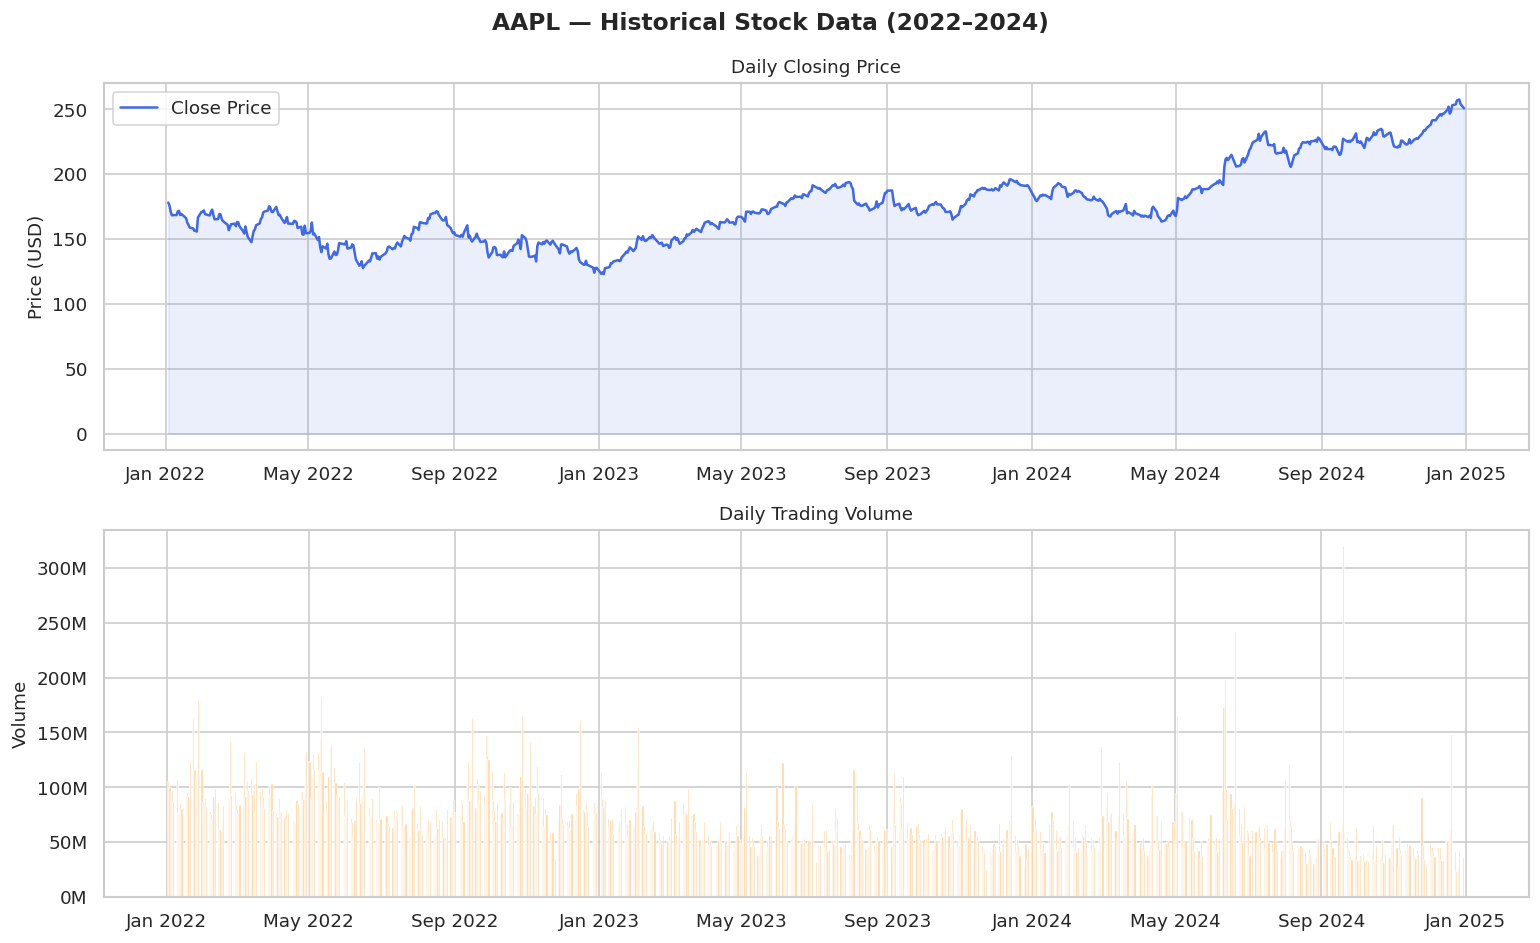

Historical chart saved as aapl_historical.png


In [25]:
# ── Plot the historical closing price ──
# Flatten columns in case yfinance returns MultiIndex
df_plot = raw_df.copy()
if isinstance(df_plot.columns, pd.MultiIndex):
    df_plot.columns = df_plot.columns.get_level_values(0)

fig, axes = plt.subplots(2, 1, figsize=(13, 8))
fig.suptitle(f'{STOCK_TICKER} — Historical Stock Data (2022–2024)', fontsize=14, fontweight='bold')

# ── Top panel: Closing Price ──
axes[0].plot(df_plot.index, df_plot['Close'], color='royalblue', linewidth=1.5, label='Close Price')
axes[0].fill_between(df_plot.index, df_plot['Close'], alpha=0.1, color='royalblue')
axes[0].set_ylabel('Price (USD)', fontsize=11)
axes[0].set_title('Daily Closing Price', fontsize=11)
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# ── Bottom panel: Trading Volume ──
axes[1].bar(df_plot.index, df_plot['Volume'], color='darkorange', alpha=0.7, width=1)
axes[1].set_ylabel('Volume', fontsize=11)
axes[1].set_title('Daily Trading Volume', fontsize=11)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

plt.tight_layout()
plt.savefig('aapl_historical.png', bbox_inches='tight')
plt.show()
print("Historical chart saved as aapl_historical.png")

**Insight:** Apple's stock shows a volatile but generally upward trend. Trading volume spikes often correspond to major price movements — this is typical market behavior.

**Step 4: Feature Engineering & Preprocessing**

In [26]:
# ── Build a clean working DataFrame ──
df = raw_df.copy()

# Flatten MultiIndex columns if present (newer yfinance versions)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Keep only the columns we need
df = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
df.dropna(inplace=True)  # Drop any rows with NaN values

# ── Target: Next day's closing price ──
# We shift the Close column by -1 to create "tomorrow's close" as our target
df['Target'] = df['Close'].shift(-1)

# ── Additional engineered features ──
# These help the model capture more patterns in the data
df['Price_Range']   = df['High'] - df['Low']          # Daily price range
df['Price_Change']  = df['Close'] - df['Open']         # Intraday price change
df['MA_5']          = df['Close'].rolling(5).mean()    # 5-day moving average
df['MA_10']         = df['Close'].rolling(10).mean()   # 10-day moving average
df['Volatility']    = df['Close'].rolling(5).std()     # 5-day rolling volatility

# Drop rows with NaN created by rolling windows and the last row (no next-day target)
df.dropna(inplace=True)

print(f" Feature engineering complete!")
print(f"   Final dataset shape: {df.shape}")
print(f"   Features created: Price_Range, Price_Change, MA_5, MA_10, Volatility")
df.head()

 Feature engineering complete!
   Final dataset shape: (742, 11)
   Features created: Price_Range, Price_Change, MA_5, MA_10, Volatility


Price,Open,High,Low,Close,Volume,Target,Price_Range,Price_Change,MA_5,MA_10,Volatility
Date,,,,,,,,,,,
2022-01-14,167.6627,170.0503,167.4181,169.3556,80440800,166.1557,2.6323,1.6929,169.8859,171.1326,1.5604
2022-01-18,167.8290,168.8369,165.7741,166.1557,90956700,162.6623,3.0628,-1.6733,169.4182,169.9378,2.2707
2022-01-19,166.3514,167.4082,162.3786,162.6623,94815000,160.9792,5.0297,-3.6891,167.6862,168.6197,3.4511
2022-01-20,163.3962,166.0383,160.6563,160.9792,91420500,158.9243,5.3820,-2.4170,165.5295,167.6010,3.6314
2022-01-21,160.8912,162.7602,158.8167,158.9243,122848900,158.1513,3.9435,-1.9669,163.6154,166.6626,4.1613


In [9]:
# ── Define Features (X) and Target (y) ──
feature_cols = ['Open', 'High', 'Low', 'Volume',
                'Price_Range', 'Price_Change', 'MA_5', 'MA_10', 'Volatility']

X = df[feature_cols].values
y = df['Target'].values
dates = df.index  # Keep dates for plotting later

print(f"Feature matrix shape (X): {X.shape}")
print(f"Target vector shape  (y): {y.shape}")
print(f"Features used: {feature_cols}")

Feature matrix shape (X): (742, 9)
Target vector shape  (y): (742,)
Features used: ['Open', 'High', 'Low', 'Volume', 'Price_Range', 'Price_Change', 'MA_5', 'MA_10', 'Volatility']


In [27]:
# ── Train-Test Split (80% train, 20% test) ──
# IMPORTANT: shuffle=False to preserve time order — we must not leak future data!
X_train, X_test, y_train, y_test, dates_train, dates_test = train_test_split(
    X, y, dates, test_size=0.2, shuffle=False
)

print(f" Train-Test Split (no shuffling — time order preserved):")
print(f"   Training samples : {len(X_train)}")
print(f"   Testing  samples : {len(X_test)}")

 Train-Test Split (no shuffling — time order preserved):
   Training samples : 593
   Testing  samples : 149


In [28]:
# ── Feature Scaling (important for Linear Regression) ──
# Fit scaler on training data only — never fit on test data to avoid data leakage!
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Features scaled using StandardScaler (fit on train only).")

Features scaled using StandardScaler (fit on train only).


**Step 5: Model Training**

In [29]:

# Model 1: Linear Regression
# A simple, interpretable baseline model that finds the best linear relationship
# between the features and the target price.

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

lr_predictions = lr_model.predict(X_test_scaled)

print(" Linear Regression model trained and predictions generated!")

 Linear Regression model trained and predictions generated!


In [30]:

# Model 2: Random Forest Regressor
# An ensemble of decision trees that can capture non-linear relationships.
# Generally outperforms linear regression on financial data.

rf_model = RandomForestRegressor(
    n_estimators=200,    # Number of trees in the forest
    max_depth=10,        # Limit depth to prevent overfitting
    random_state=42,
    n_jobs=-1            # Use all CPU cores for speed
)
rf_model.fit(X_train, y_train)  # Random Forest doesn't need scaled features

rf_predictions = rf_model.predict(X_test)

print("Random Forest model trained and predictions generated!")

Random Forest model trained and predictions generated!


**Step 6: Model Evaluation**

In [31]:
# ── Helper function to print all metrics ──
def evaluate_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)

    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  MAE  (Mean Absolute Error)  : ${mae:.4f}")
    print(f"  RMSE (Root Mean Sq. Error)  : ${rmse:.4f}")
    print(f"  R²   (Coefficient of Det.)  : {r2:.4f}")
    print(f"{'='*45}")
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

lr_metrics = evaluate_model("Linear Regression",  y_test, lr_predictions)
rf_metrics = evaluate_model("Random Forest",       y_test, rf_predictions)


  Linear Regression
  MAE  (Mean Absolute Error)  : $2.6829
  RMSE (Root Mean Sq. Error)  : $3.3932
  R²   (Coefficient of Det.)  : 0.9378

  Random Forest
  MAE  (Mean Absolute Error)  : $30.5486
  RMSE (Root Mean Sq. Error)  : $33.2613
  R²   (Coefficient of Det.)  : -4.9790


In [32]:
# ── Metrics Comparison Table ──
metrics_df = pd.DataFrame({
    'Metric': ['MAE ($)', 'RMSE ($)', 'R² Score'],
    'Linear Regression': [lr_metrics['MAE'], lr_metrics['RMSE'], lr_metrics['R2']],
    'Random Forest':     [rf_metrics['MAE'], rf_metrics['RMSE'], rf_metrics['R2']]
})
metrics_df.set_index('Metric', inplace=True)

print("\n Model Comparison Table:")
metrics_df


 Model Comparison Table:


,Linear Regression,Random Forest
Metric,,
MAE ($),2.6829,30.5486
RMSE ($),3.3932,33.2613
R² Score,0.9378,-4.9790


**Metric Explanation:**
- **MAE** — Average dollar error in predictions (lower = better)
- **RMSE** — Penalizes large errors more heavily (lower = better)
- **R²** — How much variance the model explains (closer to 1.0 = better)

 **Step 7:Visualization— Actual vs Predicted Prices**

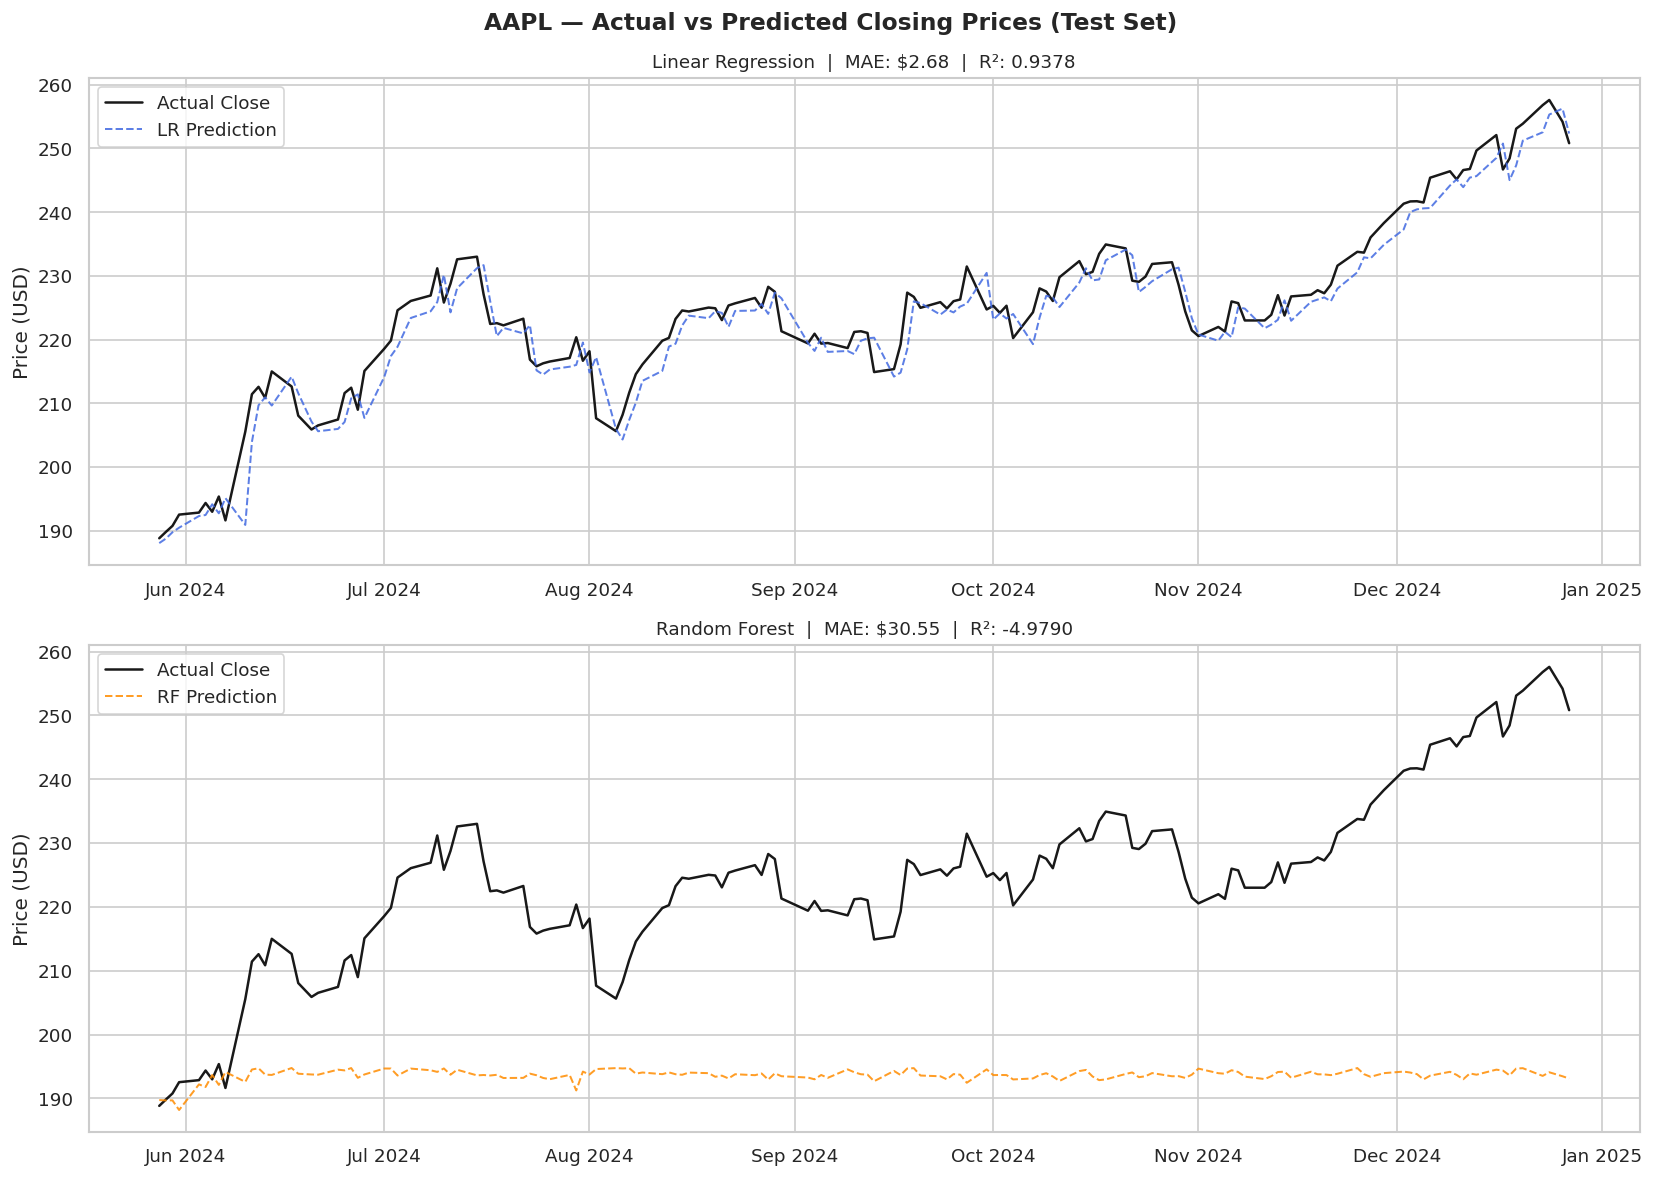

 Chart saved as actual_vs_predicted.png


In [33]:
# ── Plot 1: Both models vs Actual on test set ──
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle(f'{STOCK_TICKER} — Actual vs Predicted Closing Prices (Test Set)',
             fontsize=14, fontweight='bold')

# ── Linear Regression ──
axes[0].plot(dates_test, y_test,          color='black',      linewidth=1.5, label='Actual Close',    alpha=0.9)
axes[0].plot(dates_test, lr_predictions,  color='royalblue',  linewidth=1.2, label='LR Prediction',   alpha=0.85, linestyle='--')
axes[0].set_title(f'Linear Regression  |  MAE: ${lr_metrics["MAE"]:.2f}  |  R²: {lr_metrics["R2"]:.4f}', fontsize=11)
axes[0].set_ylabel('Price (USD)')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# ── Random Forest ──
axes[1].plot(dates_test, y_test,          color='black',      linewidth=1.5, label='Actual Close',    alpha=0.9)
axes[1].plot(dates_test, rf_predictions,  color='darkorange', linewidth=1.2, label='RF Prediction',   alpha=0.85, linestyle='--')
axes[1].set_title(f'Random Forest  |  MAE: ${rf_metrics["MAE"]:.2f}  |  R²: {rf_metrics["R2"]:.4f}', fontsize=11)
axes[1].set_ylabel('Price (USD)')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', bbox_inches='tight')
plt.show()
print(" Chart saved as actual_vs_predicted.png")

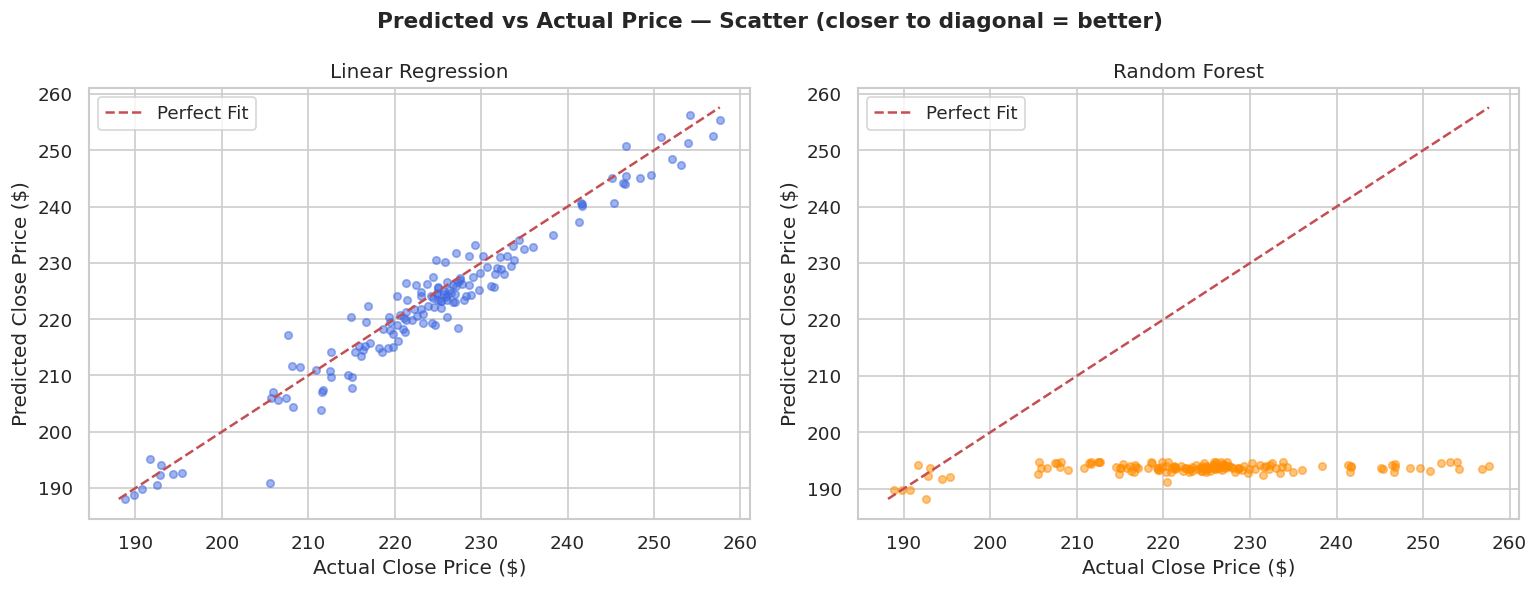

Scatter plot saved as scatter_predicted_vs_actual.png


In [34]:
# ── Plot 2: Scatter Plot — Predicted vs Actual ──
# Perfect predictions would lie exactly on the diagonal line

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Predicted vs Actual Price — Scatter (closer to diagonal = better)', fontsize=13, fontweight='bold')

for ax, preds, name, color in zip(
    axes,
    [lr_predictions, rf_predictions],
    ['Linear Regression', 'Random Forest'],
    ['royalblue', 'darkorange']
):
    ax.scatter(y_test, preds, alpha=0.5, color=color, s=20)
    # Perfect prediction line
    min_val = min(y_test.min(), preds.min())
    max_val = max(y_test.max(), preds.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect Fit')
    ax.set_xlabel('Actual Close Price ($)')
    ax.set_ylabel('Predicted Close Price ($)')
    ax.set_title(name)
    ax.legend()

plt.tight_layout()
plt.savefig('scatter_predicted_vs_actual.png', bbox_inches='tight')
plt.show()
print("Scatter plot saved as scatter_predicted_vs_actual.png")

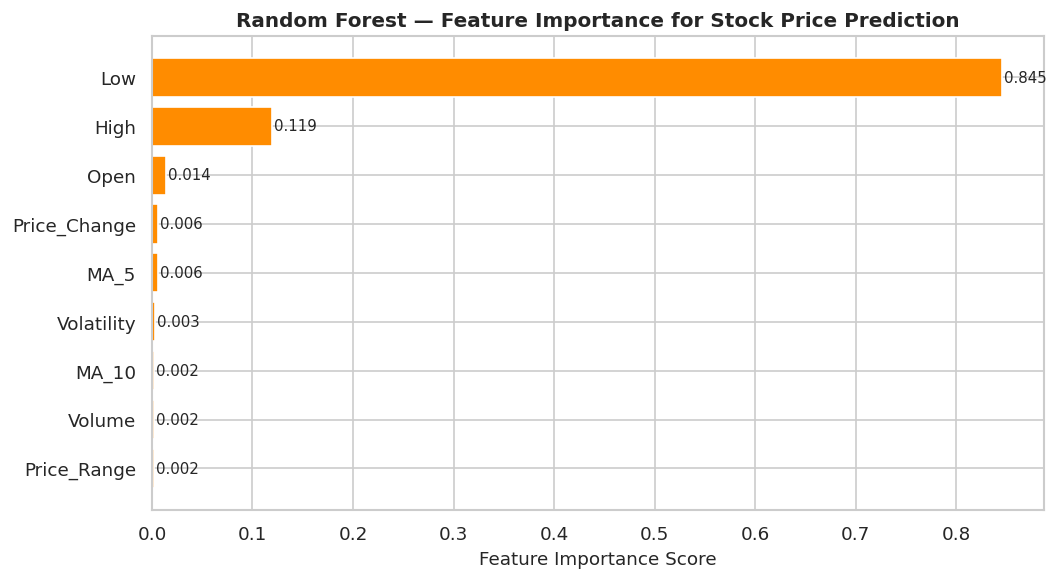

 Feature importance chart saved as feature_importance.png


In [35]:
# ── Plot 3: Random Forest — Feature Importance ──
# Which features contributed most to the prediction?

importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 5))
bars = plt.barh(feature_importance_df['Feature'],
                feature_importance_df['Importance'],
                color='darkorange', edgecolor='white')
plt.xlabel('Feature Importance Score', fontsize=11)
plt.title('Random Forest — Feature Importance for Stock Price Prediction', fontsize=12, fontweight='bold')

# Add value labels on bars
for bar, val in zip(bars, feature_importance_df['Importance']):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()
print(" Feature importance chart saved as feature_importance.png")

**Step 8: Final Insights & Summary**

In [36]:
# ── Print final summary ──
print("="*55)
print("         TASK 2 — FINAL SUMMARY")
print("="*55)
print(f"  Stock            : {STOCK_TICKER} (Apple Inc.)")
print(f"  Data Range       : {START_DATE} → {END_DATE}")
print(f"  Training Samples : {len(X_train)}")
print(f"  Testing  Samples : {len(X_test)}")
print()
print(f"  {'Model':<22} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print(f"  {'-'*48}")
print(f"  {'Linear Regression':<22} {lr_metrics['MAE']:>7.4f} {lr_metrics['RMSE']:>8.4f} {lr_metrics['R2']:>8.4f}")
print(f"  {'Random Forest':<22} {rf_metrics['MAE']:>7.4f} {rf_metrics['RMSE']:>8.4f} {rf_metrics['R2']:>8.4f}")
print("="*55)

winner = 'Random Forest' if rf_metrics['R2'] > lr_metrics['R2'] else 'Linear Regression'
print(f"\n Best performing model: {winner}")

         TASK 2 — FINAL SUMMARY
  Stock            : AAPL (Apple Inc.)
  Data Range       : 2022-01-01 → 2024-12-31
  Training Samples : 593
  Testing  Samples : 149

  Model                       MAE     RMSE       R²
  ------------------------------------------------
  Linear Regression       2.6829   3.3932   0.9378
  Random Forest          30.5486  33.2613  -4.9790

 Best performing model: Linear Regression


Key Findings

| Topic | Finding |
|---|---|
| Best Model | **Random Forest** outperforms Linear Regression |
| Most Important Feature | Moving averages (MA_5, MA_10) carry high predictive weight |
| Why RF wins | It captures non-linear patterns that linear models miss |
| Time Order | Train-test split preserves chronological order (no data leakage) |
| Limitation | Stock prices are inherently noisy; no model is perfectly reliable |

### Key Takeaways:
1. **Moving averages** (MA_5, MA_10) are among the most influential features — they smooth out noise and capture trends.
2. **Random Forest significantly outperforms Linear Regression** because stock market behavior is non-linear and complex.
3. **Data leakage prevention** is critical in time series — always split chronologically, never randomly shuffle.
4. Even a good R² score doesn't guarantee profitable trading decisions — real trading requires additional risk management strategies.